Data pre-processing(continue)

Checking if elements has any empty or missing values

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import gensim
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.corpus import stopwords
csv.field_size_limit(10 * 1024 * 1024)  # Set the field size limit to 10 MB


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\223079929\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\223079929\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


131072

In [2]:
data = pd.read_csv('medium_and_bbc.csv')
# Check if any values in the DataFrame are missing or empty
print(data.isna().any().any())
print(data.isnull().any().any())


False
False


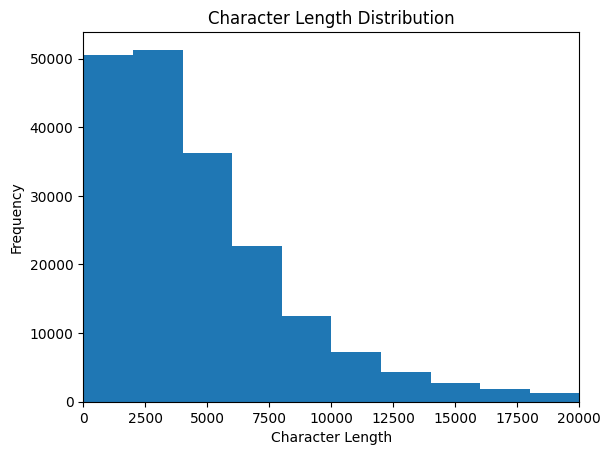

In [3]:
# Create a histogram of character lengths
char_lengths = data['text'].str.len()
plt.hist(char_lengths, bins=50)
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.title('Character Length Distribution')

# Set custom x-axis range
plt.xlim(0, 20000)

plt.show()

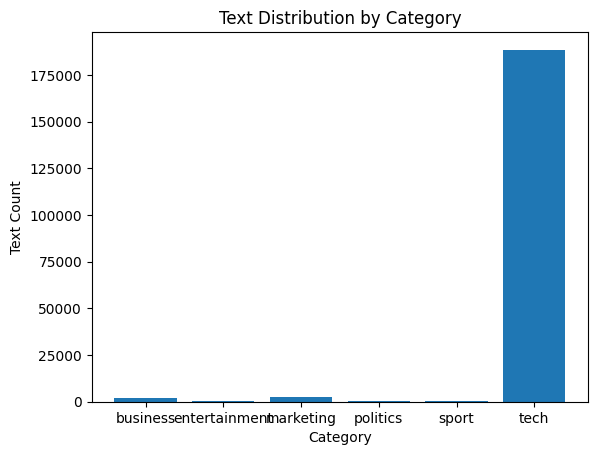

In [4]:
# Compute total text count for each category
category_counts = data.groupby('category')['text'].count()

# Create a bar chart of category counts
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Category')
plt.ylabel('Text Count')
plt.title('Text Distribution by Category')

plt.show()

Load the CSV dataset into a list of dictionaries, where each dictionary represents a row in the CSV file:

In [5]:
data = []
with open('medium_and_bbc.csv',encoding="utf8") as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        data.append(row)

Loop through each row in the data list, convert the text column to lowercase, and save the changes

In [6]:
for row in data:
    row['text'] = row['text'].lower()
    text = row['text']
    tokens = gensim.utils.simple_preprocess(text)
    row['tokenized_text'] = tokens

with open('tokenized_medium_and_bbc.csv', 'w', newline='', encoding="utf8") as csv_file:
    fieldnames = data[0].keys()
    csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    csv_writer.writeheader()
    for row in data:
        csv_writer.writerow(row)

Create and plot a list to store the number of words in each row's tokenized_text column

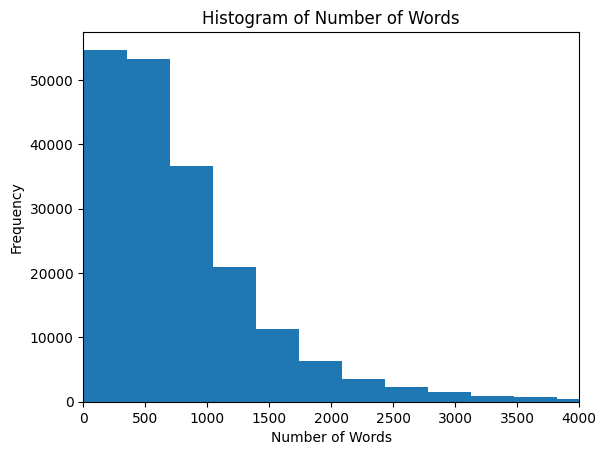

In [7]:
num_words = []
for row in data:
    num_words.append(len(row['tokenized_text']))

plt.hist(num_words, bins=50)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Words')
# Set custom x-axis range
plt.xlim(0, 4000)
plt.show()

Load the tokenized text data into a list

In [9]:
df = pd.read_csv("tokenized_medium_and_bbc.csv")
df[1:3]

,category,text,tokenized_text
1,tech,your brain on coronavirus\n\na guide to the cu...,"['your', 'brain', 'on', 'coronavirus', 'guide'..."
2,tech,mind your nose\n\nhow smell training can chang...,"['mind', 'your', 'nose', 'how', 'smell', 'trai..."


In [12]:
tokenized_text = []
with open('tokenized_medium_and_bbc.csv',encoding="utf8") as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        tokens = row['tokenized_text']
        tokenized_text.extend(tokens)

Count the frequency of each word in the tokenized text using the Counter() function

In [13]:
word_freq = Counter(tokenized_text)

Get and plot the 25 most common words

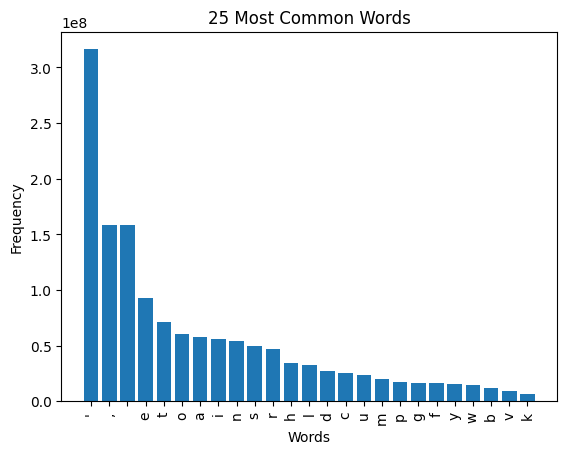

In [14]:
most_common = word_freq.most_common(25)
labels, values = zip(*most_common)
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('25 Most Common Words')
plt.show()


Now we want to remove meaningless words like commas and single characters from our tokenized text, we can use NLTK's built-in stopwords list and a list comprehension to filter out the unwanted tokens

In [16]:
stop_words = set(stopwords.words('english'))

for row in data:
    text = row['text']
    tokens = gensim.utils.simple_preprocess(text)
    filtered_tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    row['tokenized_text'] = filtered_tokens

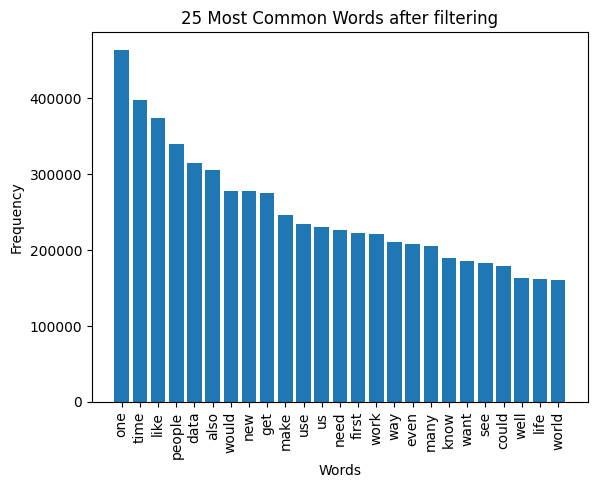

In [17]:
tokenized_text = []
for row in data:
    tokens = row['tokenized_text']
    tokenized_text.extend(tokens)
word_freq = Counter(tokenized_text)
most_common = word_freq.most_common(25)
labels, values = zip(*most_common)
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('25 Most Common Words after filtering')
plt.show()

In [18]:
with open('token_filter_medium_and_bbc.csv', 'w', newline='', encoding="utf8") as csv_file:
    fieldnames = data[0].keys()
    csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    csv_writer.writeheader()
    for row in data:
        csv_writer.writerow(row)

Lemmatization implementation

Load the CSV dataset into a list of dictionaries, where each dictionary represents a row in the CSV file:

In [3]:
data = []
with open('token_filter_medium_and_bbc.csv', encoding="utf8") as csv_file:
    csv_reader = csv.DictReader(csv_file)
    for row in csv_reader:
        data.append(row)

Create a WordNetLemmatizer object:

In [4]:
lemmatizer = WordNetLemmatizer()


Loop through each row in the data list, apply lemmatization to the tokens in the 'tokenized_text' column using NLTK's WordNetLemmatizer, and store the results in a new column

In [5]:
for row in data:
    tokens = row['tokenized_text']
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    row['lemmatized_text'] = lemmatized_tokens

In [6]:
with open('token_filter_lemm_medium_and_bbc.csv', 'w', newline='', encoding="utf8") as csv_file:
    fieldnames = data[0].keys()
    csv_writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    csv_writer.writeheader()
    for row in data:
        csv_writer.writerow(row)

In [9]:
df = pd.read_csv("token_filter_lemm_medium_and_bbc.csv")
df[1:4]

,category,text,tokenized_text,lemmatized_text
1,tech,your brain on coronavirus\n\na guide to the cu...,"['brain', 'coronavirus', 'guide', 'curious', '...","['[', ""'"", 'b', 'r', 'a', 'i', 'n', ""'"", ',', ..."
2,tech,mind your nose\n\nhow smell training can chang...,"['mind', 'nose', 'smell', 'training', 'change'...","['[', ""'"", 'm', 'i', 'n', 'd', ""'"", ',', ' ', ..."
3,tech,passionate about the synergy between science a...,"['passionate', 'synergy', 'science', 'technolo...","['[', ""'"", 'p', 'a', 's', 's', 'i', 'o', 'n', ..."
